In [3]:
import cv2
import os

def extract_frames(video_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(f"{out_dir}/{idx:06d}.png", gray)
        idx += 1
    cap.release()


In [4]:
import csv

def load_transcript(path):
    entries = []
    with open(path) as f:
        for row in csv.reader(f):
            if len(row) < 3:
                continue
            start, end, phoneme = float(row[0]), float(row[1]), row[2]
            if phoneme == "" or phoneme == "sil":
                continue
            entries.append((start, end, phoneme))
    return entries


In [6]:
import numpy as np
from PIL import Image

def get_clip(center_time, frame_dir, fps=50, window=4):
    center_frame = int(center_time * fps)
    frames = []
    for offset in range(-window, window+1):
        idx = max(0, center_frame + offset)
        img = Image.open(f"{frame_dir}/{idx:06d}.png")
        frames.append(np.array(img))
    return np.stack(frames, axis=0)  # shape: (T, H, W)


In [ ]:
clips = []
labels = []

for start, end, ph in transcript:
    center = (start + end) / 2
    clip = get_clip(center, frame_dir)
    clips.append(clip)
    labels.append(ph)

In [ ]:
import cv2
cap = cv2.VideoCapture("path/to/file.avi")
fps = cap.get(cv2.CAP_PROP_FPS)
nframes = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = nframes / fps if fps>0 else None
print(fps, nframes, duration)
cap.release()

In [10]:
import cv2
cap = cv2.VideoCapture("/Users/simone/Downloads/USC-TIMIT/MRI/Data/M1/avi/usctimit_mri_m1_001_005.avi")
fps = cap.get(cv2.CAP_PROP_FPS)
nframes = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = nframes / fps if fps>0 else None
print(fps, nframes, duration)
cap.release()

23.18 501 21.613459879206214


In [11]:
# save as collect_video_metadata.py
import subprocess, json, csv, os, sys
from pathlib import Path

def ffprobe_info(path):
    try:
        cmd = [
            "ffprobe", "-v", "error", "-select_streams", "v:0",
            "-show_entries", "stream=avg_frame_rate,nb_frames,width,height,duration",
            "-of", "json", str(path)
        ]
        out = subprocess.check_output(cmd, stderr=subprocess.DEVNULL).decode()
        j = json.loads(out)
        s = j['streams'][0]
        # avg_frame_rate might be like "2318/100"
        afr = s.get('avg_frame_rate', '0/1')
        num, den = afr.split('/')
        fps = float(num)/float(den) if float(den)!=0 else 0.0
        nb = int(s.get('nb_frames')) if s.get('nb_frames') and s.get('nb_frames').isdigit() else None
        dur = float(s.get('duration')) if s.get('duration') else (nb/fps if nb and fps>0 else None)
        return fps, nb, dur, s.get('width'), s.get('height')
    except Exception:
        return None

def opencv_info(path):
    try:
        import cv2
        cap = cv2.VideoCapture(str(path))
        fps = cap.get(cv2.CAP_PROP_FPS)
        nb = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        dur = nb / fps if fps>0 else None
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
        return fps, nb, dur, w, h
    except Exception:
        return None

root = Path("/Users/simone/Downloads/USC-TIMIT/MRI/Data/M1/avi")
outcsv = Path("video_metadata.csv")
with outcsv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["filepath","fps","nframes","duration","width","height","speaker","sentence_id"])
    for p in root.rglob("*.avi"):
        info = ffprobe_info(p)
        if not info:
            info = opencv_info(p)
        if not info:
            print("Skipping (no info):", p)
            continue
        fps, nb, dur, w, h = info
        # attempt to infer speaker/sentence from path (adjust to your layout)
        parts = p.parts
        speaker = parts[-3] if len(parts)>=3 else ""
        sentence_id = parts[-2] if len(parts)>=2 else ""
        writer.writerow([str(p), fps, nb, dur, w, h, speaker, sentence_id])
print("Wrote:", outcsv)


Wrote: video_metadata.csv


In [17]:
import os
import csv

# --- Transcript Reader -------------------------------------------------------

def load_transcript(path, keep_sil=False):
    entries = []

    with open(path, "r", encoding="utf-8") as f:
        reader = csv.reader(f)

        for line_num, row in enumerate(reader, start=1):
            if not row:
                continue

            # # --- DEBUG PRINT FOR LONG ROWS ---
            # if len(row) > 5:
            #     print("\n⚠️  Long row detected!")
            #     print(f"File: {path}")
            #     print(f"Line {line_num}: {row}")
            #     print(f"Columns: {len(row)}\n")

            # Trim extra columns
            if len(row) > 5:
                row = row[:5]

            # Pad missing
            while len(row) < 5:
                row.append("")

            start_str, end_str, ph, word, sent = row

            ph = ph.strip()
            word = word.strip() if word else ""
            sent = sent.strip() if sent else ""

            # Convert to floats
            try:
                start = float(start_str)
                end = float(end_str)
            except ValueError:
                continue

            if not keep_sil and ph.lower() == "sil":
                continue
            if ph == "":
                continue

            entries.append({
                "start": start,
                "end": end,
                "phoneme": ph,
                "word": word if word else None,
                "sentence": sent if sent else None
            })

    return entries



# --- Dataset Walker ----------------------------------------------------------

def load_speaker(root_path, speaker_id, keep_sil=False):
    """
    Loads all videos + transcripts + audio for one speaker (e.g., 'M1').

    Returns:
        {
            "001_005": {
                "avi":  "/.../avi/usctimit_mri_m1_001_005.avi",
                "wav":  "/.../wav/usctimit_mri_m1_001_005.wav",
                "transcript": [...]
            },
            ...
        }
    """
    speaker_path = os.path.join(root_path, speaker_id)

    avi_dir  = os.path.join(speaker_path, "avi")
    wav_dir  = os.path.join(speaker_path, "wav")
    trans_dir = os.path.join(speaker_path, "trans")

    speaker_data = {}

    # Look at all transcript files and use them as the anchor
    for fname in os.listdir(trans_dir):
        if not fname.endswith(".trans"):
            continue

        base = fname.replace(".trans", "")  # e.g. "usctimit_mri_m1_001_005"

        # Extract the file ID part (e.g. "001_005")
        parts = base.split("_")
        file_id = parts[-2] + "_" + parts[-1]

        trans_path = os.path.join(trans_dir, fname)

        # Expected video/audio names
        avi_path = os.path.join(avi_dir, base + ".avi")
        wav_path = os.path.join(wav_dir, base + ".wav")

        # Safety checks
        if not os.path.exists(avi_path):
            print(f"WARNING: Missing AVI for {base}")
        if not os.path.exists(wav_path):
            print(f"WARNING: Missing WAV for {base}")

        entries = load_transcript(trans_path, keep_sil=keep_sil)

        speaker_data[file_id] = {
            "avi": avi_path if os.path.exists(avi_path) else None,
            "wav": wav_path if os.path.exists(wav_path) else None,
            "transcript": entries
        }

    return speaker_data


def load_all_speakers(root_path, keep_sil=False):
    """
    Loads M1..Mn, F1..Fn automatically.
    Returns:
        {
            "M1": {...speaker_data...},
            "M2": {...},
            ...
            "F5": {...}
        }
    """
    dataset = {}

    for speaker_id in sorted(os.listdir(root_path)):
        speaker_dir = os.path.join(root_path, speaker_id)
        if not os.path.isdir(speaker_dir):
            continue

        # Only accept M1/M2/.../F5
        if not (speaker_id.startswith("M") or speaker_id.startswith("F")):
            continue

        print(f"Loading {speaker_id}...")
        dataset[speaker_id] = load_speaker(root_path, speaker_id, keep_sil=keep_sil)

    return dataset


In [20]:
root = "/Users/simone/Downloads/USC-TIMIT/MRI/Data"   # contains M1/ M2/ ... F5/

all_data = load_all_speakers(root, keep_sil=False)

# Example: access data
print(all_data["M1"].keys())              # all utterances
print(all_data["M1"]["001_005"]["avi"])   # path to video
print(all_data["M1"]["001_005"]["transcript"][:3])   # first few transcript entries


Loading F1...
Loading F2...
Loading F3...
Loading F4...
Loading F5...
Loading M1...
Loading M2...
Loading M3...
Loading M4...
Loading M5...
dict_keys(['146_150', '281_285', '351_355', '026_030', '156_160', '231_235', '191_195', '041_045', '386_390', '121_125', '256_260', '326_330', '131_135', '246_250', '436_440', '051_055', '181_185', '406_410', '221_225', '341_345', '416_420', '291_295', '086_090', '361_365', '336_340', '201_205', '426_430', '071_075', '316_320', '441_445', '266_270', '096_100', '276_280', '111_115', '306_310', '101_105', '451_455', '061_065', '036_040', '176_180', '211_215', '006_010', '371_375', '166_170', '016_020', '126_130', '056_060', '331_335', '046_050', '381_385', '251_255', '021_025', '411_415', '091_095', '141_145', '286_290', '346_350', '151_155', '081_085', '401_405', '356_360', '226_230', '031_035', '241_245', '391_395', '196_200', '186_190', '321_325', '456_460', '301_305', '446_450', '236_240', '261_265', '011_015', '376_380', '206_210', '421_425', '1

In [21]:
FPS = 23.18

def phoneme_to_frame_range(start_sec, end_sec, fps=FPS):
    start_f = int(start_sec * fps)
    end_f   = int(end_sec * fps)
    return start_f, end_f


import cv2
import numpy as np

def load_video_frames(path, start_frame, end_frame):
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        print(f"Could not open: {path}")
        return None

    frames = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    for f in range(start_frame, end_frame + 1):
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)   # MRI is grayscale
        frame = frame.astype(np.float32) / 255.0          # normalize
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        return None

    return np.stack(frames)

def build_phoneme_dataset(all_data, fps=FPS, max_frames=12):
    samples = []

    for speaker_id, utts in all_data.items():
        print(f"Building samples for {speaker_id}...")

        for file_id, item in utts.items():
            avi = item["avi"]
            transcript = item["transcript"]

            if avi is None:
                continue

            for entry in transcript:
                ph = entry["phoneme"]
                start_sec = entry["start"]
                end_sec = entry["end"]

                start_f, end_f = phoneme_to_frame_range(start_sec, end_sec, fps)

                # Limit duration for easier training
                if end_f - start_f > max_frames:
                    end_f = start_f + max_frames

                frames = load_video_frames(avi, start_f, end_f)
                if frames is None:
                    continue

                samples.append({
                    "phoneme": ph,
                    "frames": frames,
                    "speaker": speaker_id,
                    "file": file_id
                })

    return samples


In [22]:
max_frames = 9
phoneme_data = build_phoneme_dataset(all_data)
print("Total samples:", len(phoneme_data))


Building samples for F1...
Building samples for F2...
Building samples for F3...
Building samples for F4...
Building samples for F5...
Building samples for M1...
Building samples for M2...
Building samples for M3...
Building samples for M4...
Building samples for M5...
Total samples: 139080


In [28]:
import torch
from torch.utils.data import Dataset
import numpy as np
import cv2


FPS = 23.18


def sec_to_frame(t, fps=FPS):
    return int(t * fps)


class MRIPhonemeDataset(Dataset):
    def __init__(self, all_data, max_frames=9, resize=128, include_sil=False):
        self.samples = []
        self.max_frames = max_frames
        self.resize = resize

        for speaker, utts in all_data.items():
            for file_id, item in utts.items():

                if item["avi"] is None:
                    continue

                avi_path = item["avi"]
                transcript = item["transcript"]

                for t in transcript:
                    ph = t["phoneme"]

                    if (not include_sil) and ph.lower() == "sil":
                        continue

                    start_f = sec_to_frame(t["start"])
                    end_f   = sec_to_frame(t["end"])

                    if end_f - start_f > max_frames:
                        end_f = start_f + max_frames

                    self.samples.append({
                        "phoneme": ph,
                        "avi": avi_path,
                        "start_f": start_f,
                        "end_f": end_f,
                        "speaker": speaker
                    })

        # build label vocabulary
        self.phonemes = sorted(list({s["phoneme"] for s in self.samples}))
        self.ph_to_idx = {ph: i for i, ph in enumerate(self.phonemes)}

    def __len__(self):
        return len(self.samples)

    def load_frames(self, path, start_f, end_f):
        cap = cv2.VideoCapture(path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_f)

        frames = []
        for f in range(start_f, end_f + 1):
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frame = cv2.resize(frame, (self.resize, self.resize))
            frame = frame.astype(np.float32) / 255.0
            frames.append(frame)

        cap.release()

        if len(frames) == 0:
            return None

        return np.stack(frames)  # T × H × W

    def __getitem__(self, idx):
        s = self.samples[idx]
    
        # Calculate center frame between start and end frames
        mid_frame = (s["start_f"] + s["end_f"]) // 2
        
        half_clip = self.max_frames // 2  # assuming max_frames is clip length
        
        # Determine new start and end frames centered on mid_frame
        start_f = max(0, mid_frame - half_clip)
        end_f = start_f + self.max_frames - 1
        
        # Optional: If you know total frames, clamp end_f here
        # total_frames = ... (if available)
        # if end_f >= total_frames:
        #     end_f = total_frames - 1
        #     start_f = max(0, end_f - self.max_frames + 1)
        
        # Load frames from video using your method
        frames = self.load_frames(s["avi"], start_f, end_f)
        
        if frames is None:
            # fallback: zero tensor if extraction fails (rare)
            frames = np.zeros((self.max_frames, self.resize, self.resize), dtype=np.float32)
        
        # Convert to tensor: shape T × 1 × H × W (time first, 1 channel)
        frames = torch.tensor(frames).unsqueeze(1)
        
        label = self.ph_to_idx[s["phoneme"]]
    
        return {
            "frames": frames,
            "phoneme": s["phoneme"],
            "label": torch.tensor(label, dtype=torch.long),
            "speaker": s["speaker"]
        }



In [27]:
transcript_path = "/Users/simone/Downloads/USC-TIMIT/MRI/Data/M1/trans/usctimit_mri_m1_001_005.trans"

entries = load_transcript(transcript_path, keep_sil=False)

print(entries)


[{'start': 1.59, 'end': 1.63, 'phoneme': 'dh', 'word': 'this', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.63, 'end': 1.67, 'phoneme': 'ih', 'word': 'this', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.67, 'end': 1.7, 'phoneme': 's', 'word': 'this', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.7, 'end': 1.75, 'phoneme': 'sp', 'word': None, 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.75, 'end': 1.81, 'phoneme': 'w', 'word': 'was', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.81, 'end': 1.86, 'phoneme': 'ah', 'word': 'was', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.86, 'end': 1.94, 'phoneme': 'z', 'word': 'was', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.94, 'end': 2.08, 'phoneme': 'iy', 'word': 'easy', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 2.08, 'end': 2.13, 'phoneme': 'z', 'word': 'easy', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 2.13, 'end': 2.29, 'phoneme': 'iy', 'word': 'easy', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 2.29, 'end

In [29]:
import os

root_dir = "/Users/simone/Downloads/USC-TIMIT/MRI/Data"
speakers = ["M1", "M2", "M2", "M3", "M4", "M5", "F1", "F2", "F3", "F4", "F5"]  # all your speakers
phonemes_set = set()

for spk in speakers:
    trans_folder = os.path.join(root_dir, spk, "trans")
    for fname in os.listdir(trans_folder):
        if not fname.endswith(".trans"):
            continue
        with open(os.path.join(trans_folder, fname), "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) < 3:
                    continue
                ph = parts[2].strip()
                if ph:
                    phonemes_set.add(ph)

print("Phonemes found in dataset:")
print(sorted(phonemes_set))


Phonemes found in dataset:
['aa', 'ae', 'ah', 'ao', 'aw', 'ay', 'b', 'ch', 'd', 'dh', 'eh', 'er', 'ey', 'f', 'g', 'ga', 'hh', 'ih', 'iy', 'jh', 'k', 'l', 'm', 'n', 'ng', 'ow', 'oy', 'p', 'r', 's', 'sh', 'sil', 'sp', 't', 'th', 'uh', 'uw', 'v', 'w', 'y', 'z', 'zh']


In [32]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class MRIPhonemeDataset(Dataset):
    def __init__(self, root_dir, speakers, ph_to_idx, max_frames=10, fps=23.18, resize=64, keep_sil=False):
        """
        root_dir: root folder with speakers (M1, F1, ...)
        speakers: list of speaker IDs to load
        ph_to_idx: dict phoneme -> int label
        max_frames: number of frames per clip
        fps: video frames per second
        resize: size to resize each frame (assumes square)
        keep_sil: whether to keep silence phonemes
        """
        self.root_dir = root_dir
        self.speakers = speakers
        self.ph_to_idx = ph_to_idx
        self.max_frames = max_frames
        self.fps = fps
        self.resize = resize
        self.keep_sil = keep_sil

        # Samples will be dicts with keys:
        # "avi", "start_f", "end_f", "phoneme", "speaker"
        self.samples = []
        self._build_samples()

    def _load_transcript(self, trans_path):
        entries = []
        with open(trans_path, 'r') as f:
            for line in f:
                row = line.strip().split(',')
                if len(row) < 3:
                    continue
                start, end, ph = float(row[0]), float(row[1]), row[2].strip()
                if not self.keep_sil and ph.lower() == 'sil':
                    continue
                entries.append((start, end, ph))
        return entries

    def _build_samples(self):
        for spk in self.speakers:
            trans_folder = os.path.join(self.root_dir, spk, 'trans')
            avi_folder = os.path.join(self.root_dir, spk, 'avi')
            for fname in os.listdir(trans_folder):
                if not fname.endswith('.trans'):
                    continue
                base = fname[:-6]  # remove ".trans"
                trans_path = os.path.join(trans_folder, fname)
                avi_path = os.path.join(avi_folder, base + '.avi')
                if not os.path.exists(avi_path):
                    print(f"Missing AVI for {base}")
                    continue
                transcript = self._load_transcript(trans_path)
                for (start, end, ph) in transcript:
                    if ph not in self.ph_to_idx:
                        continue
                    # Convert times to frames
                    start_f = int(start * self.fps)
                    end_f = int(end * self.fps)
                    self.samples.append({
                        "avi": avi_path,
                        "start_f": start_f,
                        "end_f": end_f,
                        "phoneme": ph,
                        "speaker": spk
                    })

    def load_frames(self, avi_path, start_frame, end_frame):
        cap = cv2.VideoCapture(avi_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Clamp frame indices to video length
        start_frame = max(0, start_frame)
        end_frame = min(end_frame, total_frames - 1)

        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        frames = []
        for _ in range(start_frame, end_frame + 1):
            ret, frame = cap.read()
            if not ret:
                break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            # Resize frame
            gray = cv2.resize(gray, (self.resize, self.resize))
            frames.append(gray)
        cap.release()

        if len(frames) == 0:
            return None

        # Pad or truncate frames to max_frames
        if len(frames) > self.max_frames:
            frames = frames[:self.max_frames]
        elif len(frames) < self.max_frames:
            pad_frame = np.zeros_like(frames[0])
            frames += [pad_frame] * (self.max_frames - len(frames))

        frames_np = np.stack(frames, axis=0).astype(np.float32) / 255.0  # normalize
        return frames_np

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # Calculate midpoint frame to center clip
        mid_frame = (s["start_f"] + s["end_f"]) // 2
        half_len = self.max_frames // 2
        start_f = mid_frame - half_len
        end_f = start_f + self.max_frames - 1

        frames = self.load_frames(s["avi"], start_f, end_f)
        if frames is None:
            frames = np.zeros((self.max_frames, self.resize, self.resize), dtype=np.float32)

        frames_tensor = torch.tensor(frames).unsqueeze(1)  # T x 1 x H x W

        label = self.ph_to_idx[s["phoneme"]]

        return {
            "frames": frames_tensor,
            "phoneme": s["phoneme"],
            "label": torch.tensor(label, dtype=torch.long),
            "speaker": s["speaker"]
        }


if __name__ == "__main__":
    root = "/Users/simone/Downloads/USC-TIMIT/MRI/Data"
    speakers = ["M1", "M2", "M3", "M4", "M5", "F1", "F2", "F3", "F4", "F5"]


    phonemes = ['aa', 'ae', 'ah', 'ao', 'aw', 'ay', 'b', 'ch', 'd', 'dh', 'eh', 'er', 'ey', 'f', 'g', 'ga', 
            'hh', 'ih', 'iy', 'jh', 'k', 'l', 'm', 'n', 'ng', 'ow', 'oy', 'p', 'r', 's', 'sh', 'sil', 
            'sp', 't', 'th', 'uh', 'uw', 'v', 'w', 'y', 'z', 'zh']

    ph_to_idx = {p: i for i, p in enumerate(phonemes)}

    dataset = MRIPhonemeDataset(root, speakers, ph_to_idx, max_frames=10, resize=64)

    print(f"Dataset size: {len(dataset)}")

    loader = DataLoader(dataset, batch_size=4, shuffle=True)

    for batch in loader:
        print(f"Batch frames shape: {batch['frames'].shape}")  # (batch_size, T, 1, H, W)
        print(f"Batch labels: {batch['label']}")
        break


Dataset size: 28929
Batch frames shape: torch.Size([4, 10, 1, 64, 64])
Batch labels: tensor([28, 23,  8,  2])


In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Simple3DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple3DCNN, self).__init__()
        
        self.conv1 = nn.Conv3d(1, 16, kernel_size=(3,3,3), padding=1)  # input channels=1 (grayscale)
        self.bn1 = nn.BatchNorm3d(16)
        self.pool1 = nn.MaxPool3d((1,2,2))  # pool spatial dims only
        
        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3,3,3), padding=1)
        self.bn2 = nn.BatchNorm3d(32)
        self.pool2 = nn.MaxPool3d((2,2,2))  # pool temporal + spatial dims
        
        self.conv3 = nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=1)
        self.bn3 = nn.BatchNorm3d(64)
        self.pool3 = nn.AdaptiveAvgPool3d((1,1,1))  # global avg pool
        
        self.fc = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, channels=1, T, H, W)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [36]:
def top_k_accuracy(output, target, k=5):
    with torch.no_grad():
        max_k = min(k, output.size(1))
        _, pred = output.topk(max_k, 1, True, True)  # top k indices
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        correct_k = correct[:max_k].reshape(-1).float().sum(0)
        return correct_k.item()

In [35]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = len(ph_to_idx)
model = Simple3DCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5

from tqdm import tqdm

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    loop = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in loop:
        inputs = batch['frames'].permute(0,2,1,3,4).to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        
        # Update tqdm description dynamically
        loop.set_postfix(loss=epoch_loss, accuracy=epoch_acc)
    
    print(f"Epoch {epoch+1} completed: Loss={epoch_loss:.4f}, Accuracy={epoch_acc:.4f}")


Using device: cpu


Epoch 1/5: 100%|█| 7233/7233 [05:51<00:00, 20.58it/s, accuracy=0.0736, loss=3.45


Epoch 1 completed: Loss=3.4500, Accuracy=0.0736


Epoch 2/5: 100%|█| 7233/7233 [18:44<00:00,  6.43it/s, accuracy=0.0861, loss=3.37


Epoch 2 completed: Loss=3.3729, Accuracy=0.0861


...

Epoch 3 completed: Loss=3.2767, Accuracy=0.1042


Epoch 4/5: 100%|█| 7233/7233 [06:25<00:00, 18.75it/s, accuracy=0.128, loss=3.18]


Epoch 4 completed: Loss=3.1837, Accuracy=0.1279


Epoch 5/5: 100%|█| 7233/7233 [07:19<00:00, 16.44it/s, accuracy=0.149, loss=3.09]

Epoch 5 completed: Loss=3.0873, Accuracy=0.1495


In [38]:
import torch
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split  # handy splitting tool

# Assume you already created the full dataset with all speakers
speakers = ["M1", "M2", "M3", "M4", "M5", "F1", "F2", "F3", "F4", "F5"]

full_dataset = MRIPhonemeDataset(root, speakers, ph_to_idx, max_frames=10, resize=64)

# Total number of samples
num_samples = len(full_dataset)
all_indices = list(range(num_samples))

# Split into train (80%), temp (20%)
train_indices, temp_indices = train_test_split(all_indices, test_size=0.2, random_state=42, shuffle=True)

# Split temp into validation (10%) and test (10%)
val_indices, test_indices = train_test_split(temp_indices, test_size=0.5, random_state=42, shuffle=True)

print(f"Train samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Test samples: {len(test_indices)}")

# Create subset datasets
train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


Missing AVI for usctimit_mri_m3_331_335
Train samples: 111319
Validation samples: 13915
Test samples: 13915


In [39]:
import os

def save_checkpoint(state, filename="checkpoint.pth.tar"):
    torch.save(state, filename)
    print(f"Checkpoint saved to {filename}")


In [40]:
def load_checkpoint(model, optimizer, filename="checkpoint.pth.tar"):
    if os.path.isfile(filename):
        print(f"Loading checkpoint '{filename}'")
        checkpoint = torch.load(filename)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_acc = checkpoint.get('best_val_acc', 0)
        print(f"Loaded checkpoint '{filename}' (epoch {checkpoint['epoch']})")
        return start_epoch, best_val_acc
    else:
        print(f"No checkpoint found at '{filename}', starting fresh")
        return 0, 0


In [48]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(ph_to_idx)
model = Simple3DCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

checkpoint_path = "checkpoint.pth.tar"

def save_checkpoint(state, filename=checkpoint_path):
    torch.save(state, filename)
    print(f"Checkpoint saved to {filename}")

def load_checkpoint(model, optimizer, filename=checkpoint_path):
    if os.path.isfile(filename):
        print(f"Loading checkpoint '{filename}'")
        checkpoint = torch.load(filename)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_acc = checkpoint.get('best_val_acc', 0)
        print(f"Loaded checkpoint '{filename}' (epoch {checkpoint['epoch']})")
        return start_epoch, best_val_acc
    else:
        print(f"No checkpoint found at '{filename}', starting fresh")
        return 0, 0

def top_k_accuracy(output, target, k=5):
    with torch.no_grad():
        max_k = min(k, output.size(1))
        _, pred = output.topk(max_k, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        correct_k = correct[:max_k].reshape(-1).float().sum(0)
        return correct_k.item()

# Load checkpoint if exists
start_epoch, best_val_acc = load_checkpoint(model, optimizer, checkpoint_path)

num_epochs = 40

for epoch in range(start_epoch, num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    top5_correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for batch in loop:
        inputs = batch['frames'].permute(0,2,1,3,4).to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        top5_correct += top_k_accuracy(outputs, labels, k=5)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        epoch_top5_acc = top5_correct / total

        loop.set_postfix(loss=epoch_loss, acc=epoch_acc, top5_acc=epoch_top5_acc)

    print(f"Epoch {epoch+1} TRAIN Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f}, Top5Acc={epoch_top5_acc:.4f}")

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_top5_correct = 0
    val_total = 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        for batch in val_loop:
            inputs = batch['frames'].permute(0,2,1,3,4).to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_top5_correct += top_k_accuracy(outputs, labels, k=5)

            val_loss_avg = val_loss / val_total
            val_acc = val_correct / val_total
            val_top5_acc = val_top5_correct / val_total

            val_loop.set_postfix(val_loss=val_loss_avg, val_acc=val_acc, val_top5_acc=val_top5_acc)

    print(f"Epoch {epoch+1} VAL Loss={val_loss_avg:.4f}, Acc={val_acc:.4f}, Top5Acc={val_top5_acc:.4f}")

    # Save checkpoint if val accuracy improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_checkpoint({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc
        }, checkpoint_path)

# After training: test evaluation (optional)
model.eval()
test_loss = 0.0
test_correct = 0
test_top5_correct = 0
test_total = 0

with torch.no_grad():
    test_loop = tqdm(test_loader, desc="Testing")
    for batch in test_loop:
        inputs = batch['frames'].permute(0,2,1,3,4).to(device)
        labels = batch['label'].to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        test_top5_correct += top_k_accuracy(outputs, labels, k=5)

        test_loss_avg = test_loss / test_total
        test_acc = test_correct / test_total
        test_top5_acc = test_top5_correct / test_total

        test_loop.set_postfix(test_loss=test_loss_avg, test_acc=test_acc, test_top5_acc=test_top5_acc)

print(f"Test Loss={test_loss_avg:.4f}, Accuracy={test_acc:.4f}, Top-5 Accuracy={test_top5_acc:.4f}")


Loading checkpoint 'checkpoint.pth.tar'
Loaded checkpoint 'checkpoint.pth.tar' (epoch 19)


Epoch 21/40 [Train]: 100%|█| 27830/27830 [26:28<00:00, 17.52it/s, acc=0.367, los


Epoch 21 TRAIN Loss=2.3529, Acc=0.3666, Top5Acc=0.7117


Epoch 21/40 [Val]: 100%|█| 3479/3479 [01:27<00:00, 39.68it/s, val_acc=0.355, val


Epoch 21 VAL Loss=2.4130, Acc=0.3545, Top5Acc=0.6982


...

Epoch 36 TRAIN Loss=2.2268, Acc=0.3993, Top5Acc=0.7367


Epoch 36/40 [Val]: 100%|█| 3479/3479 [16:09<00:00,  3.59it/s, val_acc=0.369, val


Epoch 36 VAL Loss=2.3734, Acc=0.3694, Top5Acc=0.7069


Epoch 37/40 [Train]:   5%| | 1271/27830 [08:32<2:58:35,  2.48it/s, acc=0.41, los


KeyboardInterrupt: 

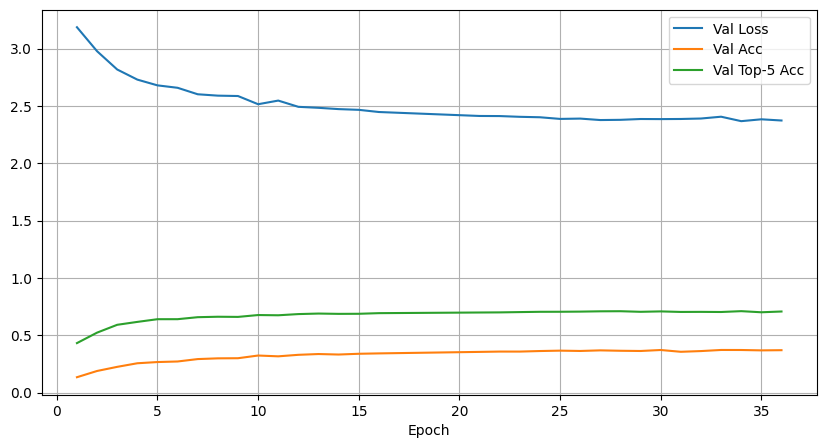

In [50]:
epochs = [
    1,2,3,4,5,
    6,7,8,9,10,
    11,12,13,14,15,16,
    21,22,23,24,25,26,27,28,29,30,
    31,32,33,34,35,36
]
val_loss = [
    3.1873, 2.9779, 2.8184, 2.7302, 2.6800,
    2.6588, 2.6023, 2.5903, 2.5870, 2.5155,
    2.5472, 2.4927, 2.4841, 2.4728, 2.4665, 2.4475,
    2.4130, 2.4121, 2.4056, 2.4017, 2.3873, 2.3901, 2.3774,
    2.3793, 2.3864, 2.3856, 2.3867, 2.3907, 2.4065,
    2.3677, 2.3839, 2.3734
]
val_acc = [
    0.1335, 0.1880, 0.2240, 0.2553, 0.2659,
    0.2708, 0.2918, 0.2982, 0.2993, 0.3228,
    0.3158, 0.3290, 0.3358, 0.3315, 0.3381, 0.3414,
    0.3545, 0.3573, 0.3572, 0.3620, 0.3654, 0.3626, 0.3678,
    0.3643, 0.3624, 0.3710, 0.3554, 0.3617, 0.3713,
    0.3710, 0.3677, 0.3694
]
val_top5 = [
    0.4312, 0.5226, 0.5909, 0.6162, 0.6397,
    0.6399, 0.6573, 0.6612, 0.6598, 0.6760,
    0.6740, 0.6844, 0.6890, 0.6863, 0.6870, 0.6925,
    0.6982, 0.6992, 0.7018, 0.7043, 0.7046, 0.7059, 0.7086,
    0.7094, 0.7042, 0.7078, 0.7031, 0.7037, 0.7026,
    0.7099, 0.7002, 0.7069
]
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(epochs, val_loss, label="Val Loss")
plt.plot(epochs, val_acc, label="Val Acc")
plt.plot(epochs, val_top5, label="Val Top-5 Acc")
plt.xlabel("Epoch")
plt.legend()
plt.grid()
plt.show()
